# Calibration 02 — Full 2019-2020 Fit

**모델 변경 적용 후 본격 calibration**:
- 시즌성 β(t) — DiseaseParameters.seasonality_amp 추가 (20D vector)
- ILI target first-peak masking — 봄철 2차 봉 제외 (week ≥ 26 weight=0)
- initial_immunity 0.3 — effective R0 감소, epidemic 속도 조절
- t_span (0, 364) — 시즌 52주 전체 시뮬레이션 (zero-padding 손실 제거)
- Nelder-Mead max_iterations=2000 — 20D 공간 충분 탐색

**예상 실행 시간**: 2000 evals × ~1초 = **30-40분**. 한 셀씩 천천히 진행.

In [1]:
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

from kt_epimodel.calibration.ili_target import load_ili_target, simulation_to_ili
from kt_epimodel.calibration.optimizer import (
    optimize_calibration, save_result, load_result,
)
from kt_epimodel.calibration.simple_model import (
    build_aggregated_inputs, simulate_aggregated,
)
from kt_epimodel.model.parameters import (
    DiseaseParameters, ModelParameters,
)

OUT = Path('../outputs/calibration'); OUT.mkdir(parents=True, exist_ok=True)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

## 1. Nelder-Mead 본격 fit (예상 30-40분)

20D 공간을 충분히 탐색하기 위해 max_iterations=2000.

In [2]:
t0 = time.time()
result_nm = optimize_calibration(
    season='2019-2020',
    seed_total=100.0,
    initial_immunity=0.3,
    initial_vaccinated_fraction=0.0,
    method='Nelder-Mead',
    max_iterations=2000,
    first_peak_only=True,
    first_peak_end_week=26,
    t_span=(0.0, 364.0),
    verbose=True,
)
print(f"\nTotal elapsed: {(time.time() - t0) / 60:.1f} min")

save_result(result_nm, OUT / '2019-2020_NM_full.json')
print(f'Saved -> {OUT}/2019-2020_NM_full.json')

=== Optimizing 2019-2020 with Nelder-Mead ===
Initial NLL: 4990.36
[Eval   10] β=(0.050,0.050,0.050,0.050) γ_r=0.500 amp=0.300  NLL=4875.28
[Eval   20] β=(0.050,0.050,0.050,0.050) γ_r=0.500 amp=0.300  NLL=4982.84
[Eval   30] β=(0.050,0.050,0.050,0.050) γ_r=0.505 amp=0.303  NLL=4809.55
[Eval   40] β=(0.051,0.050,0.051,0.051) γ_r=0.503 amp=0.289  NLL=4694.59
[Eval   50] β=(0.051,0.051,0.052,0.049) γ_r=0.503 amp=0.304  NLL=4626.44
[Eval   60] β=(0.051,0.050,0.052,0.051) γ_r=0.494 amp=0.301  NLL=4551.34
[Eval   70] β=(0.051,0.050,0.052,0.051) γ_r=0.501 amp=0.301  NLL=4479.47
[Eval   80] β=(0.051,0.050,0.053,0.051) γ_r=0.500 amp=0.302  NLL=4389.73
[Eval   90] β=(0.051,0.050,0.053,0.051) γ_r=0.499 amp=0.297  NLL=4261.01
[Eval  100] β=(0.052,0.050,0.054,0.052) γ_r=0.497 amp=0.300  NLL=4161.23
[Eval  110] β=(0.052,0.050,0.055,0.052) γ_r=0.499 amp=0.299  NLL=4064.04
[Eval  120] β=(0.052,0.049,0.055,0.052) γ_r=0.498 amp=0.299  NLL=3914.84
[Eval  130] β=(0.052,0.052,0.056,0.052) γ_r=0.497 amp=0.2

/Users/hwcho/Documents/python/NIMS/kt_epimodel/src/kt_epimodel/calibration/optimizer.py:110: RuntimeWarning: Maximum number of iterations has been exceeded.
  sol = minimize(


## 2. L-BFGS-B 비교 fit (예상 5-15분)

Gradient 방식 — 더 빠르지만 local minimum 가능.

In [3]:
result_lbfgs = optimize_calibration(
    season='2019-2020',
    seed_total=100.0,
    initial_immunity=0.3,
    method='L-BFGS-B',
    max_iterations=500,
    first_peak_only=True,
    first_peak_end_week=26,
    t_span=(0.0, 364.0),
    verbose=True,
)
save_result(result_lbfgs, OUT / '2019-2020_LBFGS_full.json')
print(f'Saved -> {OUT}/2019-2020_LBFGS_full.json')

=== Optimizing 2019-2020 with L-BFGS-B ===
Initial NLL: 4990.36
[Eval   10] β=(0.050,0.050,0.050,0.050) γ_r=0.500 amp=0.300  NLL=4990.36
[Eval   20] β=(0.050,0.050,0.050,0.050) γ_r=0.500 amp=0.300  NLL=4990.36
[Eval   30] β=(5.000,5.000,5.000,5.000) γ_r=1.000 amp=1.000  NLL=7572.03
[Eval   40] β=(5.000,5.000,5.000,5.000) γ_r=1.000 amp=1.000  NLL=7572.03
[Eval   50] β=(1.692,1.692,1.692,1.692) γ_r=0.666 amp=0.532  NLL=7236.07
[Eval   60] β=(1.692,1.692,1.692,1.692) γ_r=0.666 amp=0.532  NLL=7236.07
[Eval   70] β=(0.591,0.591,0.591,0.591) γ_r=0.555 amp=0.376  NLL=6847.11
[Eval   80] β=(0.591,0.591,0.591,0.591) γ_r=0.555 amp=0.376  NLL=6847.11
[Eval   90] β=(0.226,0.226,0.226,0.226) γ_r=0.518 amp=0.325  NLL=4200.56
[Eval  100] β=(0.226,0.226,0.226,0.226) γ_r=0.518 amp=0.325  NLL=4200.56
[Eval  110] β=(0.197,0.197,0.212,0.192) γ_r=0.516 amp=0.325  NLL=3273.66
[Eval  120] β=(0.197,0.197,0.212,0.192) γ_r=0.516 amp=0.325  NLL=3273.66
[Eval  130] β=(0.081,0.082,0.158,0.058) γ_r=0.508 amp=0.326 

## 3. Fit 결과 시각화 — 관측 vs 예측 + φ_a

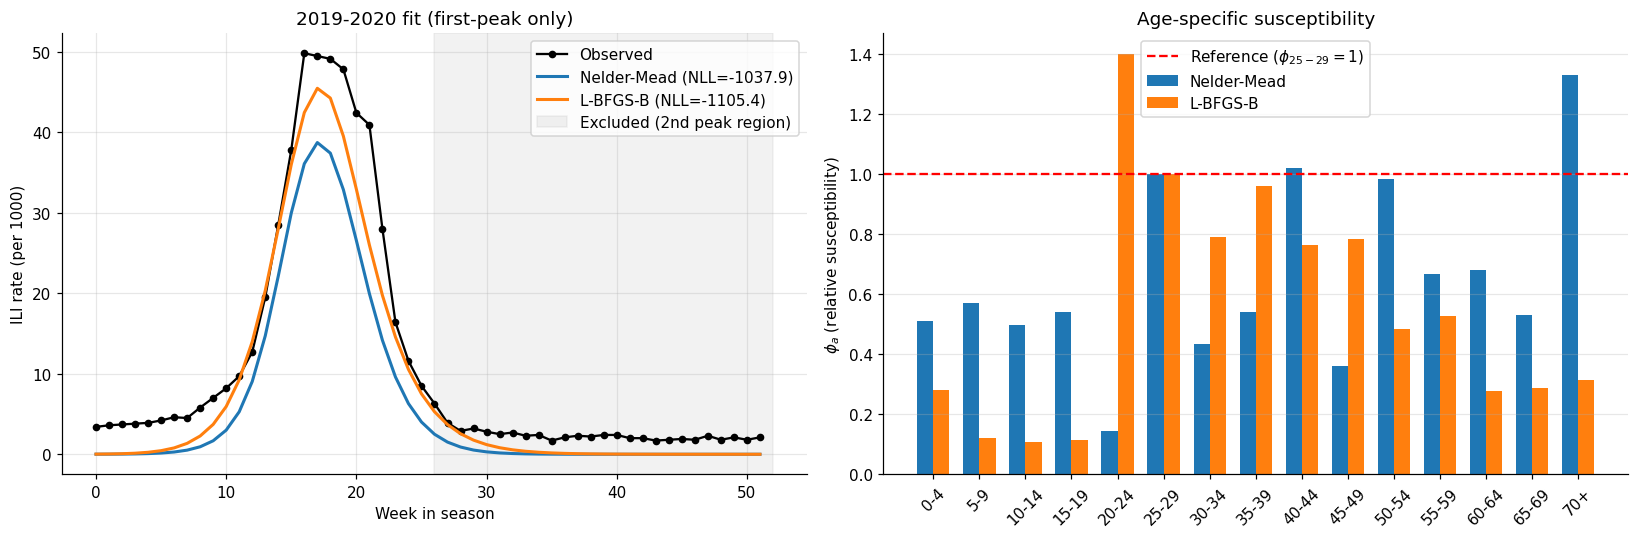

In [4]:
target = load_ili_target('2019-2020', first_peak_only=True)
observed = target['ili_rate']
weeks = np.arange(52)

inputs = build_aggregated_inputs()
pop_total = float(inputs['pop_15'].sum())

def predict(res):
    disease = DiseaseParameters(seasonality_amp=res.seasonality_amp)
    params = ModelParameters(disease=disease).with_calibration(res.calibration)
    sim = simulate_aggregated(
        params, inputs, seed_total=res.seed_total,
        initial_immunity=res.initial_immunity,
        initial_vaccinated_fraction=res.initial_vaccinated_fraction,
        t_span=(0.0, 364.0),
    )
    return simulation_to_ili(
        sim.daily_new_infection(), pop_total,
        res.calibration.gamma_report, n_weeks=52,
    )

predictions = {
    'Nelder-Mead': predict(result_nm),
    'L-BFGS-B':    predict(result_lbfgs),
}

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
ax = axes[0]
ax.plot(weeks, observed, 'ko-', label='Observed', markersize=4)
for name, pred in predictions.items():
    nll = result_nm.nll if name == 'Nelder-Mead' else result_lbfgs.nll
    ax.plot(weeks, pred, label=f'{name} (NLL={nll:.1f})', linewidth=2)
ax.axvspan(26, 52, alpha=0.1, color='gray', label='Excluded (2nd peak region)')
ax.set_xlabel('Week in season'); ax.set_ylabel('ILI rate (per 1000)')
ax.set_title('2019-2020 fit (first-peak only)')
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
ages = ['0-4','5-9','10-14','15-19','20-24','25-29','30-34','35-39',
        '40-44','45-49','50-54','55-59','60-64','65-69','70+']
x = np.arange(15); width = 0.35
ax.bar(x - width/2, result_nm.calibration.phi, width, label='Nelder-Mead')
ax.bar(x + width/2, result_lbfgs.calibration.phi, width, label='L-BFGS-B')
ax.axhline(1.0, color='red', linestyle='--', label=r'Reference ($\phi_{25-29}=1$)')
ax.set_xticks(x); ax.set_xticklabels(ages, rotation=45)
ax.set_ylabel(r'$\phi_a$ (relative susceptibility)')
ax.set_title('Age-specific susceptibility')
ax.legend(); ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(OUT / '2019-2020_fit_comparison.png', dpi=120)
plt.show()

In [5]:
summary = []
for name, res in [('Nelder-Mead', result_nm), ('L-BFGS-B', result_lbfgs)]:
    summary.append({
        'method': name,
        'nll_initial': res.nll_initial,
        'nll_final': res.nll,
        'n_evals': res.n_evaluations,
        'elapsed_min': res.elapsed_seconds / 60,
        'beta_h': res.calibration.beta_h,
        'beta_w': res.calibration.beta_w,
        'beta_s': res.calibration.beta_s,
        'beta_o': res.calibration.beta_o,
        'gamma_report': res.calibration.gamma_report,
        'seasonality_amp': res.seasonality_amp,
        'phi_min': float(res.calibration.phi.min()),
        'phi_max': float(res.calibration.phi.max()),
    })
print(pl.DataFrame(summary))

shape: (2, 13)
┌────────────┬────────────┬────────────┬─────────┬───┬────────────┬───────────┬─────────┬──────────┐
│ method     ┆ nll_initia ┆ nll_final  ┆ n_evals ┆ … ┆ gamma_repo ┆ seasonali ┆ phi_min ┆ phi_max  │
│ ---        ┆ l          ┆ ---        ┆ ---     ┆   ┆ rt         ┆ ty_amp    ┆ ---     ┆ ---      │
│ str        ┆ ---        ┆ f64        ┆ i64     ┆   ┆ ---        ┆ ---       ┆ f64     ┆ f64      │
│            ┆ f64        ┆            ┆         ┆   ┆ f64        ┆ f64       ┆         ┆          │
╞════════════╪════════════╪════════════╪═════════╪═══╪════════════╪═══════════╪═════════╪══════════╡
│ Nelder-Mea ┆ 4990.35565 ┆ -1037.9408 ┆ 2867    ┆ … ┆ 0.999871   ┆ 0.188834  ┆ 0.14419 ┆ 1.332009 │
│ d          ┆ 6          ┆ 97         ┆         ┆   ┆            ┆           ┆         ┆          │
│ L-BFGS-B   ┆ 4990.35565 ┆ -1105.4341 ┆ 5754    ┆ … ┆ 1.0        ┆ 0.03974   ┆ 0.10807 ┆ 1.399823 │
│            ┆ 6          ┆ 59         ┆         ┆   ┆            ┆         

## 4. Holdout 검증 — 2022-2023 예측 (fit에 사용 안 함)

2019-2020 fit 결과로 2022-2023 시즌 예측 — 시즌 간 일반화 확인.

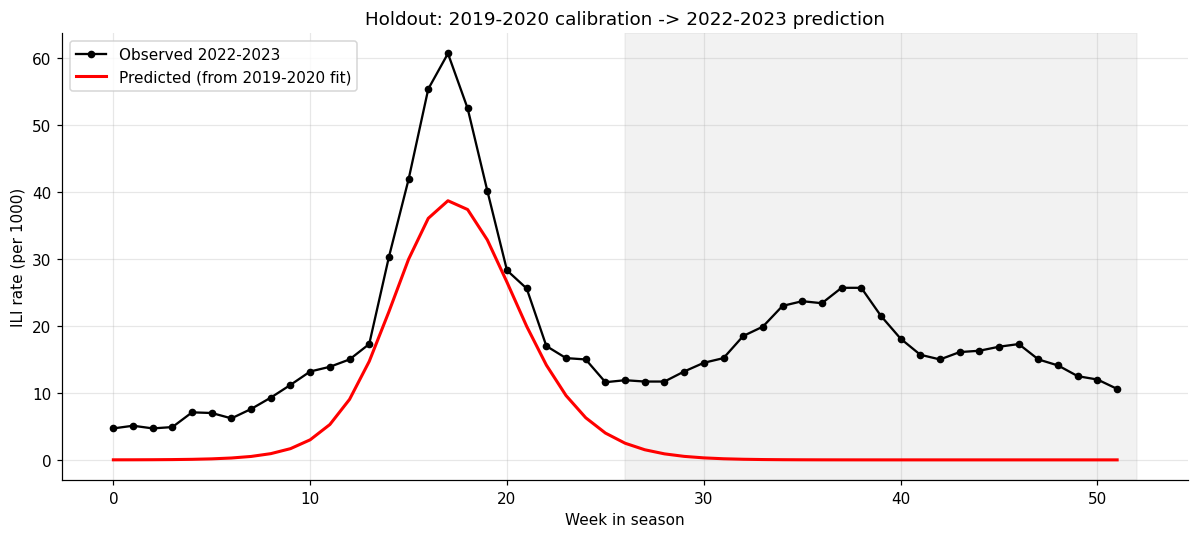

In [6]:
target_2223 = load_ili_target('2022-2023', first_peak_only=True)
observed_2223 = target_2223['ili_rate']
pred_holdout = predict(result_nm)   # 2019-2020 fit 그대로 적용

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(weeks, observed_2223, 'ko-', label='Observed 2022-2023', markersize=4)
ax.plot(weeks, pred_holdout, 'r-', linewidth=2,
        label='Predicted (from 2019-2020 fit)')
ax.axvspan(26, 52, alpha=0.1, color='gray')
ax.set_xlabel('Week in season'); ax.set_ylabel('ILI rate (per 1000)')
ax.set_title('Holdout: 2019-2020 calibration -> 2022-2023 prediction')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUT / 'holdout_2022-2023.png', dpi=120)
plt.show()

## 결론 + 다음 단계

**검증 항목**:
- Nelder-Mead 가 L-BFGS-B 보다 NLL 작아야 (gradient 없는 robust 탐색)
- predicted peak timing 이 observed (w16-18) 와 가까운지
- φ_a 가 reference (φ_25-29=1) 근방에서 reasonable variation (0.5-2.0)
- seasonality_amp 가 0~0.7 사이 합리적 값으로 수렴
- Holdout 2022-2023 도 정성적으로 합리 (다른 시즌이라 정확 fit 기대 X)

**다음 단계** (Stage 3-2-b-2):
- Sensitivity sweep (1D, 2D)
- 다른 시즌 (2018-2019, 2022-2023) 동시 fit 또는 시즌별 individual fit
- φ_25-29 reference 가정 검토 (β·φ 곱 보존 normalize 적용)